In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import itertools
import statsmodels.formula.api as smf
import statsmodels.api as sm
from biodatatools.utils.common import json_load
from mphelper import ProcessWrapPool
import pysam
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from collections import defaultdict
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from matplotlib.lines import Line2D
from statsmodels.stats.multitest import multipletests

In [2]:
matplotlib.font_manager.fontManager.addfont(f"{Path.cwd().parent}/font/Arial.ttf")
matplotlib.rcParams["font.family"] = "Arial"
bfontsize = 14
sfontsize = 12
lw = 0.8

In [3]:
PROJECT_DIR_d = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/PROcap/"
PROJECT_DIR_r = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/"
PROJECT_DIR_o = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/"

# Data preparation

In [4]:
ps = ["divergent", "unidirectional"]
ds = ["distal", "proximal"]

In [5]:
# Since we're trying to confirm if our observations remain robust after controlling for transcription level, we used the same set of elements as those in main analyses (filtered and resized as seen in "data_preprocessing/1-4.TRE_processing.ipynb")

In [6]:
# Quantify DHS and H3K27ac reads in candidate regions: refer to codes in ABC model scripts
	
def count_bam(bamfiles, bed_file, outputfile):
	dfs = []
	for bamfile in bamfiles:
		reads = pysam.AlignmentFile(bamfile)
		read_chrs = set(reads.references)
		df = pd.read_table(bed_file, header=None)
		df = df[df.columns[:3]]
		df.columns = "chr start end".split()
		counts = [(reads.count(row.chr, row.start, row.end) if (row.chr in read_chrs) else 0) for _, row in df.iterrows()]
		df["count"] = counts
		df.index = ["_".join([row["chr"], str(row["start"]), str(row["end"])]) for _, row in df.iterrows()]
		dfs.append(df)
	if len(dfs) > 1:
		total_counts = pd.concat([df["count"] for df in dfs], axis=1).sum(axis=1)
		total_df = dfs[0].drop(columns="count")
		total_df["count"] = total_counts
	else:
		total_df = dfs[0]
	total_df.to_csv(outputfile, sep="\t")

In [7]:
bamfiles = {"DNase": [f"{PROJECT_DIR_r}ENCODE/ENCFF205FNC.bam"],
			"H3K27ac": [f"{PROJECT_DIR_r}ENCODE/ENCFF121RHF.bam", f"{PROJECT_DIR_r}ENCODE/ENCFF907MNY.bam"]
		   }

In [8]:
pwpool = ProcessWrapPool(4)

for p, d in itertools.product(ps, ds):
	bed_file = f"{PROJECT_DIR_d}bed_plot/C1_{p}_{d}.bed"
	for feature in bamfiles:
		outputfile = f"{PROJECT_DIR_o}temp/{feature}_{p}_{d}.txt"
		pwpool.run(count_bam, args=[bamfiles[feature], bed_file, outputfile])

In [11]:
len(pwpool.finished_tasks)

8

In [12]:
pwpool.close()

In [13]:
def get_features(p, d):
	features = {}
	
	df1 = pd.read_table(f"{PROJECT_DIR_d}Analysis/C1_filtered_{p}_{d}_counts_DI.text", index_col=0)
	classification = 1 if p == "divergent" else 0
	features["classification"] = [classification]*len(df1)
	features["counts"] = np.log(df1["total_counts"])
	master_index = df1.index
	
	for feature in ["mappability", "gc", "phyloP", "CDTS"]:
		m = "k50" if feature == "mappability" else feature
		df2 = pd.read_table(f"{PROJECT_DIR_o}temp/{m}_{p}_{d}.txt", index_col=0)
		df2_reindexed = df2.reindex(master_index)
		if feature == "gc":
			features[feature] = list(df2_reindexed.mean(axis=1, skipna=True))
		elif feature == "phyloP":
			features[feature] = list(df2_reindexed.iloc[:, 250:751].max(axis=1, skipna=True))
		elif feature == "CDTS":
			features[feature] = list(df2_reindexed.iloc[:, 250:751].min(axis=1, skipna=True))
		else:
			features[feature] = list(df2_reindexed.iloc[:, 250:751].mean(axis=1, skipna=True))
		
	if d == "proximal":
		genes = None
	else:
		genes = json_load(f"{PROJECT_DIR_o}temp/{d}_n_genes.json")
		genes_all = {e: genes[p][e] for p in genes for e in genes[p]}
		features["n_genes"] = [genes_all[e] if e in genes_all else np.nan for e in list(master_index)]

	# Quantify DNase and H3K27ac (refer to ABC model scripts)
	for feature in ["DNase", "H3K27ac"]:
		df2 = pd.read_table(f"{PROJECT_DIR_o}temp/{feature}_{p}_{d}.txt", index_col=0)
		df2_reindexed = df2.reindex(master_index)
		features[feature] = df2["count"]

	return pd.DataFrame(features, index=master_index) 

In [14]:
df_features = {}
for d in ds:
	dfs = []
	for p in ps:
		dfs.append(get_features(p, d))
	df = pd.concat(dfs)
	df_features[d] =  df

In [16]:
# Source data for SuppTable 1

X_feature_types = ["classification", "counts", "gc", "mappability"]
Y_feature_types = ["DNase", "H3K27ac", "n_genes", "phyloP", "CDTS"]
dfs_filtered = {}
for d, Y_feature in itertools.product(ds, Y_feature_types):
	if d == "proximal" and Y_feature == "n_genes":
		continue
	dfs_filtered[(d, Y_feature)] = df_features[d][[Y_feature]+X_feature_types].dropna()
	dfs_filtered[(d, Y_feature)].to_csv(f"{PROJECT_DIR_o}source_data/SuppTable1/{d}_{Y_feature}.txt", sep="\t", index=False)

# Model selection

## Check multicollinearity

In [17]:
def plot_tables(df, outputfile, col_widths=[0.4, 0.3, 0.3], figsize=(6, 1.5)):
	fig, ax = plt.subplots(figsize=figsize)
	ax.axis("tight")
	ax.axis("off")
	table = ax.table(
		cellText=df.values,
		colLabels=df.columns,
		cellLoc="center",
		loc="center",
		colColours=["lightgray"] * len(df.columns)
	)
	table.auto_set_font_size(False)
	table.set_fontsize(10)
	table.scale(1.2, 1.8)
	
	for i, width in enumerate(col_widths):
		for (row, col), cell in table.get_celld().items():
			if col == i:
				cell.set_width(width)

	plt.savefig(outputfile, bbox_inches="tight", dpi=300, transparent=True)

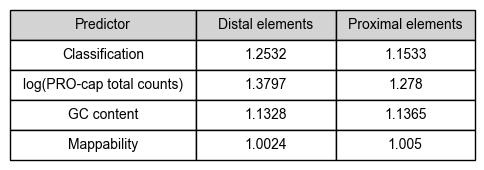

In [18]:
feature_name_map = {
    "classification": "Classification",
    "counts": "log(PRO-cap total counts)",
    "gc": "GC content",
    "mappability": "Mappability"
}

df = pd.DataFrame()
df["Predictor"] = [feature_name_map[f] for f in X_feature_types]
for d in ds:
	X = df_features[d][X_feature_types]
	X = sm.add_constant(X)
	df[f"{d.capitalize()} elements"] = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
plot_tables(df.round(4), f"{PROJECT_DIR_o}figures/comment1_vif.png")

## Count outcomes

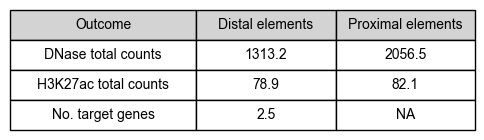

In [19]:
# Variance-to-mean ratios

df = pd.DataFrame()
df["Outcome"] = ["DNase total counts", "H3K27ac total counts", "No. target genes"]
for d in ds:
	ratios = []
	for Y_feature in Y_feature_types[:3]:
		if (d, Y_feature) in dfs_filtered:
			y = dfs_filtered[(d, Y_feature)][Y_feature]
			ratios.append((np.var(y, ddof=1)/np.mean(y)).round(1))
		else:
			ratios.append("NA")
	df[f"{d.capitalize()} elements"] = ratios
plot_tables(df, f"{PROJECT_DIR_o}figures/comment1_variance2mean.png")

Optimization terminated successfully.
         Current function value: 7.972331
         Iterations: 28
         Function evaluations: 31
         Gradient evaluations: 31
Optimization terminated successfully.
         Current function value: 4.981088
         Iterations: 33
         Function evaluations: 35
         Gradient evaluations: 35
Optimization terminated successfully.
         Current function value: 1.316845
         Iterations: 39
         Function evaluations: 41
         Gradient evaluations: 41
Optimization terminated successfully.
         Current function value: 8.400505
         Iterations: 31
         Function evaluations: 33
         Gradient evaluations: 33
Optimization terminated successfully.
         Current function value: 5.082559
         Iterations: 32
         Function evaluations: 33
         Gradient evaluations: 33


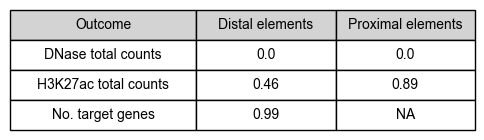

In [20]:
# Zero-inflation

outcome_name_map = {
    "DNase": "DNase total counts",
    "H3K27ac": "H3K27ac total counts",
    "n_genes": "No. target genes"
}

df = pd.DataFrame()
df["Outcome"] = [outcome_name_map[f] for f in Y_feature_types[:3]]
for d in ds:
	ratios = []
	for Y_feature in Y_feature_types[:3]:
		if (d, Y_feature) in dfs_filtered:
			obs_zeros = (dfs_filtered[(d, Y_feature)][Y_feature] == 0).sum()
			formula = f"{Y_feature} ~ C(classification)"
			for X_feature in X_feature_types[1:]:
				formula += f" + {X_feature}"
			nb_model = NegativeBinomial.from_formula(formula=formula, data=dfs_filtered[(d, Y_feature)]).fit(maxiter=100)
			mu = nb_model.predict()
			alpha = nb_model.params['alpha']
			pred_zeros = ((1 / (1 + alpha * mu)) ** (1 / alpha)).sum()
			ratios.append((obs_zeros/pred_zeros).round(2))
		else:
			ratios.append("NA")
	df[f"{d.capitalize()} elements"] = ratios
plot_tables(df, f"{PROJECT_DIR_o}figures/comment1_zeros.png")

Optimization terminated successfully.
         Current function value: 7.972331
         Iterations: 28
         Function evaluations: 31
         Gradient evaluations: 31
Optimization terminated successfully.
         Current function value: 7.972331
         Iterations: 53
         Function evaluations: 54
         Gradient evaluations: 54
Optimization terminated successfully.
         Current function value: 4.981088
         Iterations: 33
         Function evaluations: 35
         Gradient evaluations: 35
Optimization terminated successfully.
         Current function value: 4.981088
         Iterations: 34
         Function evaluations: 35
         Gradient evaluations: 35
Optimization terminated successfully.
         Current function value: 1.316845
         Iterations: 39
         Function evaluations: 41
         Gradient evaluations: 41
Optimization terminated successfully.
         Current function value: 1.316845
         Iterations: 64
         Function evaluations: 66
  

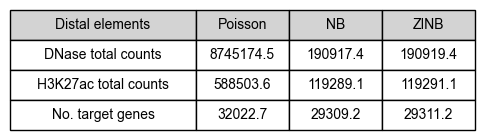

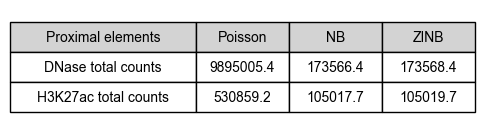

In [21]:
# AIC

for d in ds:
	df = pd.DataFrame()
	df[f"{d.capitalize()} elements"] = [outcome_name_map[f] for f in Y_feature_types[:3]] if d == "distal" else [outcome_name_map[f] for f in Y_feature_types[:2]]
	
	Y_feature_types_keep = Y_feature_types[:3] if d == "distal" else Y_feature_types[:2]
	aics = {}
	for Y_feature in Y_feature_types_keep:
		formula = f"{Y_feature} ~ C(classification)"
		for X_feature in X_feature_types[1:]:
			formula += f" + {X_feature}"
		poisson_model = smf.glm(formula=formula, data=dfs_filtered[(d, Y_feature)], family=sm.families.Poisson()).fit()
		aics[(Y_feature, "Poisson")] = poisson_model.aic.round(1)
		
		nb_model = NegativeBinomial.from_formula(formula=formula, data=dfs_filtered[(d, Y_feature)]).fit(maxiter=100)
		aics[(Y_feature, "NB")] = nb_model.aic.round(1)

		zinb_model = ZeroInflatedNegativeBinomialP.from_formula(formula, data=dfs_filtered[(d, Y_feature)], inflation='logit').fit(maxiter=100)
		aics[(Y_feature, "ZINB")] = zinb_model.aic.round(1)

	for model in ["Poisson", "NB", "ZINB"]:
		df[model] = [aics[(Y_feature, model)] for Y_feature in Y_feature_types_keep]

	plot_tables(df, f"{PROJECT_DIR_o}figures/comment1_aic_{d}.png", [0.4, 0.2, 0.2, 0.2])

## Continuous outcomes

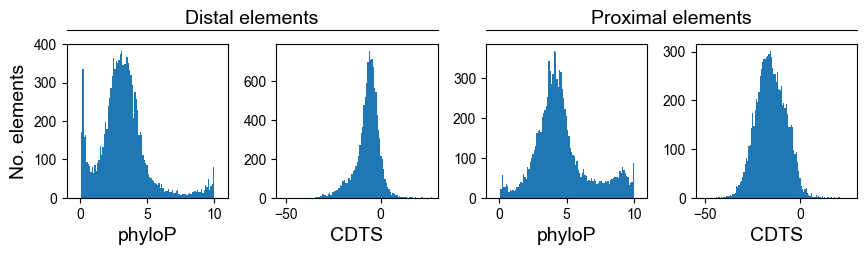

In [22]:
# Check distributions

fig, ax = plt.subplots(1, 4, figsize=(10.2, 2))
for d, Y_feature in itertools.product(ds, Y_feature_types[-2:]):
	col = ds.index(d)*2 + Y_feature_types[-2:].index(Y_feature)
	ax[col].hist(dfs_filtered[(d, Y_feature)][Y_feature], bins=100)
	ax[col].set_xlabel(Y_feature, fontsize=bfontsize)
	if col == 0:
		ax[col].set_ylabel("No. elements", fontsize=bfontsize)
	else:
		ax[col].set_ylabel("")
	if Y_feature == "phyloP":
		ax[col].set_xlim([-1,11])
	else:
		ax[col].set_xlim([-55,30])

fig.subplots_adjust(wspace=0.3, hspace=0.5)
for cols, label in [((0, 1), "Distal elements"), ((2, 3), "Proximal elements")]:
    x1 = ax[cols[0]].get_position().x0
    x2 = ax[cols[1]].get_position().x1
    fig.text((x1 + x2) / 2, 1.05, label, ha='center', va='top', fontsize=bfontsize, transform=fig.transFigure)
    fig.add_artist(Line2D([x1, x2], [0.95, 0.95], transform=fig.transFigure, c="#000000", linewidth=lw))

In [23]:
# Get residuals and fitted values

residuals = {}
fitted = {}
for d in ds:
	for Y_feature in Y_feature_types[-2:]:			
		formula = f"{Y_feature} ~ C(classification)"
		for X_feature in X_feature_types[1:]:
			formula += f" + {X_feature}"
		model = smf.ols(formula, data=dfs_filtered[(d, Y_feature)]).fit()
		residuals[(d, Y_feature)] = model.resid
		fitted[(d, Y_feature)] = model.fittedvalues

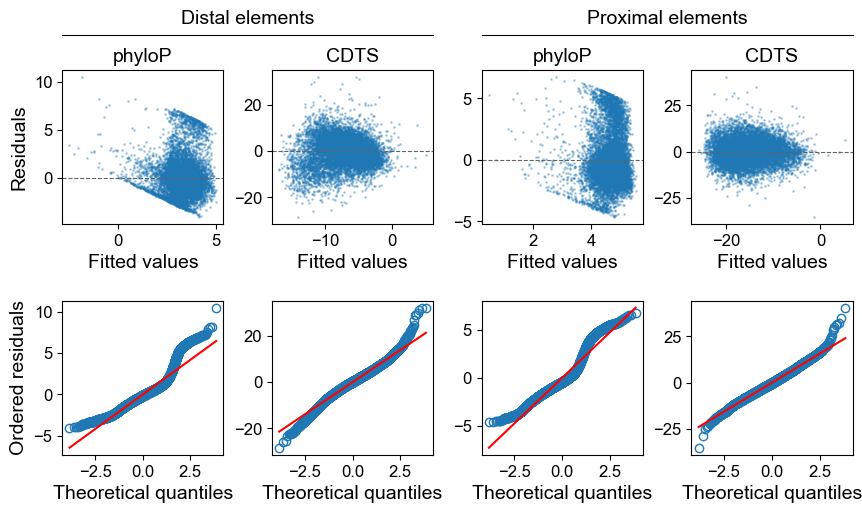

In [24]:
#1 Residuals vs. fitted values: linearity and homoscedasticity
#2 Normality of residuals

fig, ax = plt.subplots(2, 4, figsize=(10.2, 5))
for d, Y_feature in itertools.product(ds, Y_feature_types[-2:]):
	col = ds.index(d)*2 + Y_feature_types[-2:].index(Y_feature)
	
	# Residuals vs. fitted values plot
	ax[0,col].scatter(fitted[(d, Y_feature)], residuals[(d, Y_feature)], alpha=0.3, s=1)
	ax[0,col].axhline(y=0, color='#636363', linestyle='--', linewidth=lw)
	ax[0,col].set_xlabel("Fitted values", fontsize=bfontsize)
	if col == 0:
		ax[0,col].set_ylabel("Residuals", fontsize=bfontsize)
	else:
		ax[0,col].set_ylabel("")
	ax[0,col].set_title(Y_feature, fontsize=bfontsize)
	ax[0,col].tick_params(labelsize=sfontsize)

	# Q-Q plot
	stats.probplot(residuals[(d, Y_feature)], dist="norm", plot=ax[1,col])
	ax[1,col].get_lines()[0].set_markerfacecolor('none')
	ax[1,col].get_lines()[0].set_markeredgecolor('C0')
	if col == 0:
		ax[1,col].set_ylabel("Ordered residuals", fontsize=bfontsize)
	else:
		ax[1,col].set_ylabel("")
	ax[1,col].set_xlabel("Theoretical quantiles", fontsize=bfontsize)
	ax[1,col].set_title("")
	ax[1,col].tick_params(labelsize=sfontsize)
fig.subplots_adjust(wspace=0.3, hspace=0.5)

for cols, label in [((0, 1), "Distal elements"), ((2, 3), "Proximal elements")]:
    x1 = ax[0, cols[0]].get_position().x0
    x2 = ax[0, cols[1]].get_position().x1
    fig.text((x1 + x2) / 2, 1, label, ha='center', va='top', fontsize=bfontsize, transform=fig.transFigure)
    fig.add_artist(Line2D([x1, x2], [0.95, 0.95], transform=fig.transFigure, c="#000000", linewidth=lw))

plt.savefig(f"{PROJECT_DIR_o}figures/comment1_OLS_diagnostics.png", bbox_inches="tight", transparent=True, dpi=300)

# Regression results

In [25]:
model_types = ["Simple model", "Full model"]
values = defaultdict(dict)
for d, model_type in itertools.product(ds, model_types):
	Y_feature_types_all = ["DNase", "H3K27ac", "n_genes", "phyloP", "CDTS"] if d == "distal" else ["DNase", "H3K27ac", "phyloP", "CDTS"]
	for Y_feature in Y_feature_types_all:
		if model_type == "Simple model":
			formula = f"{Y_feature} ~ C(classification)"
		else:
			formula = f"{Y_feature} ~ C(classification)"
			for X_feature in X_feature_types[1:]:
				formula += f" + {X_feature}"
		if Y_feature in ["DNase", "H3K27ac", "n_genes"]:
			model = NegativeBinomial.from_formula(formula=formula, data=dfs_filtered[(d, Y_feature)]).fit(maxiter=100)
		else:
			# "HC3": heteroskedasticity-robust SE
			model = smf.ols(formula, data=dfs_filtered[(d, Y_feature)]).fit(cov_type='HC3')

		X_feature_types_keep = ["classification"] if model_type == "Simple model" else X_feature_types
		for X_feature in X_feature_types_keep:
			x = "C(classification)[T.1]" if X_feature == "classification" else X_feature
			values[(d, Y_feature)][(model_type, X_feature)] = (model.params[x], model.pvalues[x])

Optimization terminated successfully.
         Current function value: 8.087439
         Iterations: 6
         Function evaluations: 7
         Gradient evaluations: 7
Optimization terminated successfully.
         Current function value: 5.099330
         Iterations: 6
         Function evaluations: 7
         Gradient evaluations: 7
Optimization terminated successfully.
         Current function value: 1.351767
         Iterations: 6
         Function evaluations: 7
         Gradient evaluations: 7
Optimization terminated successfully.
         Current function value: 7.972331
         Iterations: 28
         Function evaluations: 31
         Gradient evaluations: 31
Optimization terminated successfully.
         Current function value: 4.981088
         Iterations: 33
         Function evaluations: 35
         Gradient evaluations: 35
Optimization terminated successfully.
         Current function value: 1.316845
         Iterations: 39
         Function evaluations: 41
         Gr

In [26]:
# BH correction for p-values

X_feature = "classification"
all_pvalues = []
all_keys = []
for d in ds:
	Y_feature_types_keep = Y_feature_types if d == "distal" else [f for f in Y_feature_types if f != "n_genes"]
	for model_type in model_types:
		for Y_feature in Y_feature_types_keep:
			coef, pvalue = values[(d, Y_feature)][(model_type, X_feature)]
			all_pvalues.append(pvalue)
			all_keys.append((d, Y_feature, model_type, X_feature))
_, qvalues, _, _ = multipletests(all_pvalues, method='fdr_bh')
qvalues_dict = {key: q for key, q in zip(all_keys, qvalues)}

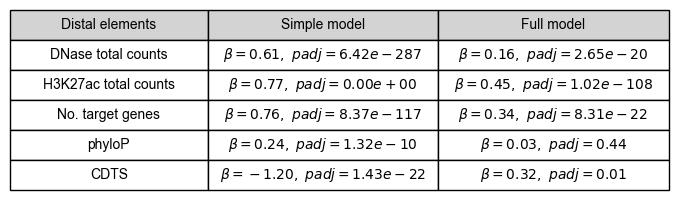

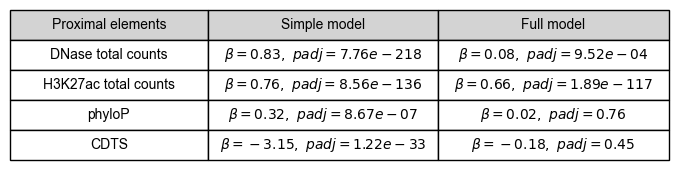

In [30]:
X_feature = "classification"
for d in ds:
	df = pd.DataFrame()
	df[f"{d.capitalize()} elements"] = ["DNase total counts", "H3K27ac total counts", "No. target genes", "phyloP", "CDTS"] if d == "distal" else ["DNase total counts", "H3K27ac total counts", "phyloP", "CDTS"]
	Y_feature_types_keep = ["DNase", "H3K27ac", "n_genes", "phyloP", "CDTS"] if d == "distal" else ["DNase", "H3K27ac", "phyloP", "CDTS"]
	for model_type in model_types:
		results = []
		for Y_feature in Y_feature_types_keep:
			coef = values[(d, Y_feature)][(model_type, X_feature)][0]
			qvalue = qvalues_dict[(d, Y_feature, model_type, X_feature)]
			v = f"$\\beta={coef:.2f},\\ padj={qvalue:.2f}$" if qvalue > 0.01 else f"$\\beta={coef:.2f},\\ padj={qvalue:.2e}$"
			results.append(v)
		df[model_type] = results
	plot_tables(df, f"{PROJECT_DIR_o}tables/SuppTable1_{d}.pdf", [0.3,0.35,0.35], (8.5,1.5))